In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from collections import defaultdict
from tqdm import tqdm

from sklearn.metrics import silhouette_score

from time_series.data_generators import LorenzGenerator
from time_series.models import KernelRidgeRegression, RascuttiModel
from time_series.evaluators import MeanSquaredError

from experiment_logging import Experiment
from time_series_clustering import TimeSeriesClustering

2026-01-07 11:15:05.917 | INFO     | time_series.config:<module>:13 - PROJ_ROOT path is: /home/james/Repo/PhD Repo/time_series_clustering
/home/james/Repo/PhD Repo/time_series_clustering/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def create_dataset(theta, n_points, n_correlated_dimensions, n_uncorrelated_dimensions, noise = 0):
    n_dim = n_correlated_dimensions + n_uncorrelated_dimensions

    # Generate transition matrix
    T = np.zeros((n_dim, n_dim))
    np.fill_diagonal(T, np.cos(theta))

    for i in range(n_correlated_dimensions - 1):
        T[i, i+1] = np.sin(theta)

    for i in range(n_correlated_dimensions - 1):
        T[i+1, i] = -np.sin(theta)

    T[1, 2] = 0 # Decouple first two dimensions from rest

    # Generate data
    xi = np.random.random(n_dim)
    x = [xi]
    for i in range(n_points):
        xi = T@xi + np.random.normal(0, noise, size=(n_dim))
        x.append(xi)

    return np.stack(x)

# MSE vs noise

## Kernel Ridge Regression

In [3]:
experiment = Experiment("MSE vs Noise - KRR - TransitionData", "experiments")

In [4]:
n_per = 5
n_groups = 3
seed = 0

shared_hparams = dict(
    bandwidth=dict(
        type=float,
        min=1e-2,
        max=4.0
    )
)

hparams = dict(
    reg=dict(
        type=float,
        min=1e-12,
        max=1e-4
    )
)

np.random.seed(seed)

experiment.add_config(
    n_per=n_per, 
    n_groups=n_groups, 
    seed=seed, 
    sweep="noise", 
    model="KRR",
    shared_hparams = shared_hparams,
    hparams = hparams
)

In [ ]:
noise_range = tqdm(np.linspace(1e-3, 10, 20))

for noise in noise_range:
    noise_range.set_description(f"Generating data for noise = {noise}")
    # Generate data groups
    datasets = []
    labels = []
    for i in range(n_groups):
        # Set group parameters
        # rho = np.random.random()*30*2
        # sigma = np.random.random()*10*2
        # beta = np.random.random()*2*2
        theta = (i/n_groups)*np.pi/2

        for n in range(n_per):
            data = create_dataset(
                theta,
                n_points=400,
                n_correlated_dimensions=3,
                n_uncorrelated_dimensions=0,
                noise=noise
            )
            # x0 = np.random.random(size=3)*10

            # generator = LorenzGenerator(
            #     noise_covariance=noise,
            #     x0=x0,
            #     dt=0.01,
            #     T=10,
            #     rho=rho,
            #     sigma=sigma,
            #     beta=beta
            # )

            # t, data = generator()

            experiment.save_dataset(
                data,
                name=f"lorenz-group_{i}-id_{n}",
                metadata=dict(
                    group = i,
                    sample_id=n,
                    data_gen_info=dict(
                        theta = theta,
                        noise=noise
                    )
                )
            )

            datasets.append(
                data
            )

            labels.append(i)

    noise_range.set_description(f"Clustering for noise = {noise}")

    clustering_model = TimeSeriesClustering(
        model_cls=KernelRidgeRegression,
        kernel="rbf",
        split=[0.5, 0.4, 0.1],
        n_trials=30,
        n_jobs=-1,
        hparams=hparams,
        shared_hparams=shared_hparams
    )

    clustering_model.fit(datasets)
    similarity_matrix = clustering_model.get_similarity_matrix()
    error_matrix = clustering_model.get_error_matrix()

    dm = 1 - similarity_matrix
    np.fill_diagonal(dm, 0)

    score = silhouette_score(dm, labels=labels, metric="precomputed")

    experiment.add_result(
        **{f"results-{noise}":dict(
                noise=float(noise),
                silhouette=float(score),
                similarity_matrix=similarity_matrix.tolist(),
                error_matrix=error_matrix.tolist()
            )
        }
    )


Clustering for noise = 0.001:   0%|          | 0/20 [00:00<?, ?it/s]     

# Dimension Scaling

In [ ]:
experiment = Experiment("MSE vs dim - KRR - TransitionData", "experiments")

In [ ]:
n_per = 5
n_groups = 3
seed = 0
n_dim_total = 20
noise = 1

np.random.seed(seed)

shared_hparams = dict(
    bandwidth=dict(
        type=float,
        min=1e-2,
        max=4.0
    )
)

hparams = dict(
    reg=dict(
        type=float,
        min=1e-12,
        max=1e-4
    )
)

experiment.add_config(
    n_per=n_per, 
    n_groups=n_groups, 
    seed=seed, 
    sweep="dimension", 
    model="KRR",
    n_dim=n_dim_total,
    noise=noise,
    shared_hparams = shared_hparams,
    hparams = hparams
)

In [ ]:
n_dim = tqdm(np.arange(3, n_dim_total, 2))

for nd in n_dim:
    n_dim.set_description(f"Generating data for noise = {nd}")
    # Generate data groups
    datasets = []
    labels = []
    for i in range(n_groups):
        # Set group parameters
        # rho = np.random.random()*30*2
        # sigma = np.random.random()*10*2
        # beta = np.random.random()*2*2
        theta = (i/n_groups)*np.pi/2

        for n in range(n_per):
            data = create_dataset(
                theta,
                n_points=400,
                n_correlated_dimensions=nd,
                n_uncorrelated_dimensions=0,
                noise=noise
            )
            # x0 = np.random.random(size=3)*10

            # generator = LorenzGenerator(
            #     noise_covariance=noise,
            #     x0=x0,
            #     dt=0.01,
            #     T=10,
            #     rho=rho,
            #     sigma=sigma,
            #     beta=beta
            # )

            # t, data = generator()

            experiment.save_dataset(
                data,
                name=f"lorenz-group_{i}-id_{n}",
                metadata=dict(
                    group = i,
                    sample_id=n,
                    data_gen_info=dict(
                        theta = theta,
                        n_points=400,
                        n_correlated_dimensions=nd,
                        n_uncorrelated_dimensions=0,
                        noise=noise
                    )
                )
            )

            datasets.append(
                data
            )

            labels.append(i)

    n_dim.set_description(f"Clustering for dimension = {nd}")

    clustering_model = TimeSeriesClustering(
        model_cls=KernelRidgeRegression,
        kernel="rbf",
        split=[0.5, 0.4, 0.1],
        n_trials=30,
        n_jobs=-1,
        hparams=hparams,
        shared_hparams=shared_hparams
    )

    clustering_model.fit(datasets)
    similarity_matrix = clustering_model.get_similarity_matrix()
    error_matrix = clustering_model.get_error_matrix()

    dm = 1 - similarity_matrix
    np.fill_diagonal(dm, 0)

    score = silhouette_score(dm, labels=labels, metric="precomputed")

    experiment.add_result(
        **{f"results-{nd}":dict(
                dimensions=float(nd),
                silhouette=float(score),
                similarity_matrix=similarity_matrix.tolist(),
                error_matrix=error_matrix.tolist()
            )
        }
    )


Clustering for noise = 1:  22%|██▏       | 2/9 [14:23<54:09, 464.25s/it]     /home/james/Repo/PhD Repo/time_series_clustering/experiments/clustering_tests/time_series_clustering.py:167: RuntimeWarning: overflow encountered in multiply
  return ip12/np.sqrt(ip11*ip22), best_score
Clustering for noise = 1:  33%|███▎      | 3/9 [41:54<1:40:37, 1006.18s/it]     /home/james/Repo/PhD Repo/time_series_clustering/experiments/clustering_tests/time_series_clustering.py:167: RuntimeWarning: overflow encountered in multiply
  return ip12/np.sqrt(ip11*ip22), best_score
Clustering for noise = 1:  44%|████▍     | 4/9 [1:37:26<2:40:21, 1924.22s/it]      /home/james/Repo/PhD Repo/time_series_clustering/experiments/clustering_tests/time_series_clustering.py:167: RuntimeWarning: overflow encountered in multiply
  return ip12/np.sqrt(ip11*ip22), best_score
Clustering for noise = 1:  56%|█████▌    | 5/9 [2:50:58<3:08:06, 2821.51s/it]      /home/james/Repo/PhD Repo/time_series_clustering/experiments/cluster

## Correlated Dimension scaling

In [ ]:
experiment = Experiment("MSE vs Correlated dim - KRR - TransitionData", "experiments")

In [ ]:
n_per = 5
n_groups = 3
seed = 0
n_dim_total = 20
noise = 1

shared_hparams = dict(
    bandwidth=dict(
        type=float,
        min=1e-2,
        max=4.0
    )
)

hparams = dict(
    reg=dict(
        type=float,
        min=1e-12,
        max=1e-4
    )
)

np.random.seed(seed)

experiment.add_config(
    n_per=n_per, 
    n_groups=n_groups, 
    seed=seed, 
    sweep="dimension", 
    model="KRR",
    n_dim=n_dim_total,
    noise=noise,
    shared_hparams = shared_hparams,
    hparams = hparams
)

In [ ]:
n_corr_dim = tqdm(np.arange(1, n_dim_total, 2))

for nd in n_corr_dim:
    n_corr_dim.set_description(f"Generating data for noise = {nd}")
    # Generate data groups
    datasets = []
    labels = []
    for i in range(n_groups):
        # Set group parameters
        # rho = np.random.random()*30*2
        # sigma = np.random.random()*10*2
        # beta = np.random.random()*2*2
        theta = (i/n_groups)*np.pi/2

        for n in range(n_per):
            data = create_dataset(
                theta,
                n_points=400,
                n_correlated_dimensions=nd,
                n_uncorrelated_dimensions=n_dim_total - nd,
                noise=noise
            )
            # x0 = np.random.random(size=3)*10

            # generator = LorenzGenerator(
            #     noise_covariance=noise,
            #     x0=x0,
            #     dt=0.01,
            #     T=10,
            #     rho=rho,
            #     sigma=sigma,
            #     beta=beta
            # )

            # t, data = generator()

            experiment.save_dataset(
                data,
                name=f"lorenz-group_{i}-id_{n}",
                metadata=dict(
                    group = i,
                    sample_id=n,
                    data_gen_info=dict(
                        theta = theta,
                        n_points=400,
                        n_correlated_dimensions=nd,
                        n_uncorrelated_dimensions=n_dim_total - nd,
                        noise=noise
                    )
                )
            )

            datasets.append(
                data
            )

            labels.append(i)

    n_corr_dim.set_description(f"Clustering for correlated dimension = {nd}")

    clustering_model = TimeSeriesClustering(
        model_cls=KernelRidgeRegression,
        kernel="rbf",
        split=[0.5, 0.4, 0.1],
        n_trials=30,
        n_jobs=-1,
        hparams=hparams,
        shared_hparams=shared_hparams
    )

    clustering_model.fit(datasets)
    similarity_matrix = clustering_model.get_similarity_matrix()
    error_matrix = clustering_model.get_error_matrix()

    dm = 1 - similarity_matrix
    np.fill_diagonal(dm, 0)

    score = silhouette_score(dm, labels=labels, metric="precomputed")

    experiment.add_result(
        **{f"results-{nd}":dict(
                correlated_dimension=float(nd),
                silhouette=float(score),
                similarity_matrix=similarity_matrix.tolist(),
                error_matrix=error_matrix.tolist()
            )
        }
    )


# Uncorrelated dimension scaling

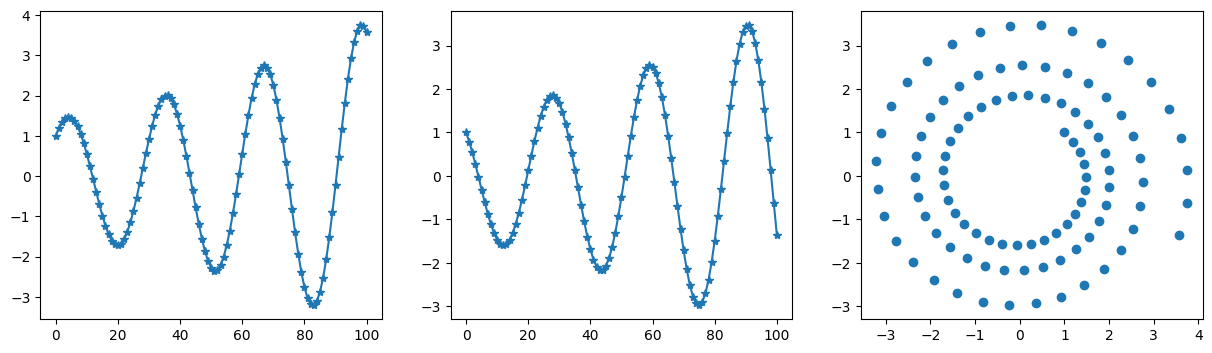

In [ ]:
d = 2

x0 = np.array([1, 1])

theta = 0.2
T = np.array(
    [[np.cos(theta), np.sin(theta)],
    [-np.sin(theta), np.cos(theta)]]
)

x = [x0]
xi = 1*x0
for i in range(100):
    xi = T@(xi)*(1 + 1e-2)
    x.append(xi)

x = np.stack(x)

fig, ax = plt.subplots(ncols=3, figsize=(15, 4))

ax[0].plot(x[:, 0], "-*")
ax[1].plot(x[:, 1], "-*")
ax[2].scatter(*x.T)

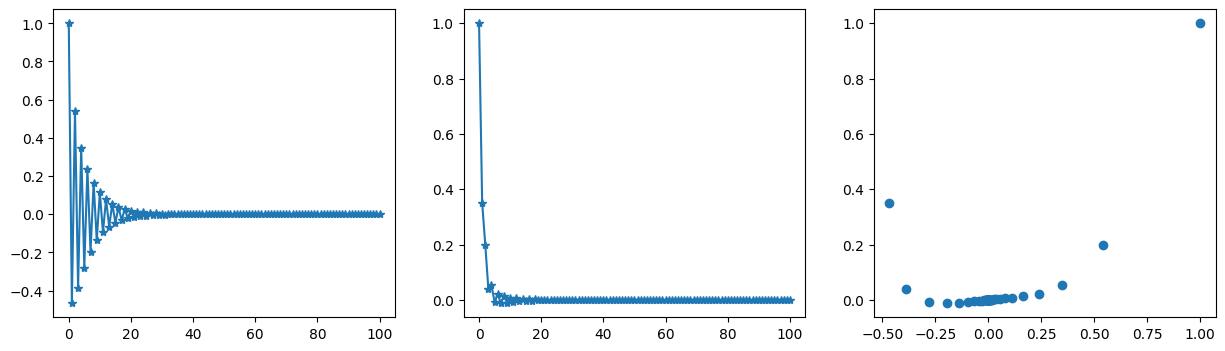

In [ ]:
d = 2

x0 = np.array([1, 1])

T = np.random.random((d, d))*2 - 1

x = [x0]
xi = 1*x0
for i in range(100):
    xi = T@(xi)
    x.append(xi)

x = np.stack(x)

fig, ax = plt.subplots(ncols=3, figsize=(15, 4))

ax[0].plot(x[:, 0], "-*")
ax[1].plot(x[:, 1], "-*")
ax[2].scatter(*x.T)

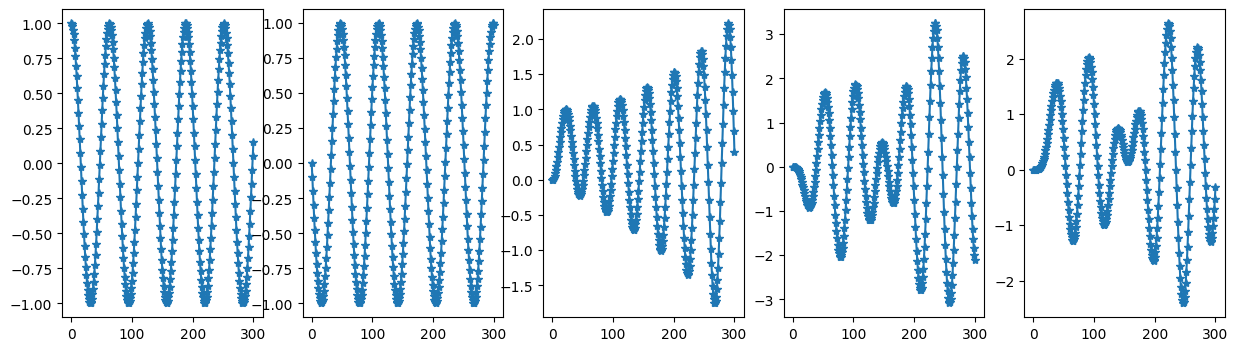

In [ ]:
d = 4

x0 = np.array([1, 0, 0, 0, 0])

# theta = 0.1
# T = np.array(
#     [
#         [np.cos(theta), np.sin(theta), 0, 0],
#         [-np.sin(theta), np.cos(theta), np.sin(theta), 0],
#         [0, -np.sin(theta), np.cos(theta), np.sin(theta)],
#         [0, 0, -np.sin(theta), np.cos(theta)],
#     ]
# )

theta = 0.1
T = np.array(
    [
        [np.cos(theta), np.sin(theta), 0, 0, 0],
        [-np.sin(theta), np.cos(theta), 0, 0, 0],
        [0, -np.sin(theta), np.cos(theta), np.sin(theta), 0],
        [0, 0, -np.sin(theta), np.cos(theta), np.sin(theta)],
        [0, 0, 0, -np.sin(theta), np.cos(theta)]
    ]
)

x = [x0]
xi = 1*x0
for i in range(300):
    xi = T@(xi)
    x.append(xi)

x = np.stack(x)

fig, ax = plt.subplots(ncols=5, figsize=(15, 4))

ax[0].plot(x[:, 0], "-*")
ax[1].plot(x[:, 1], "-*")
ax[2].plot(x[:, 2], "-*")
ax[3].plot(x[:, 3], "-*")
ax[4].plot(x[:, 4], "-*")


In [ ]:
import numpy as np

In [ ]:
def create_dataset(theta, n_points, n_correlated_dimensions, n_uncorrelated_dimensions, noise = 0):
    n_dim = n_correlated_dimensions + n_uncorrelated_dimensions

    # Generate transition matrix
    T = np.zeros((n_dim, n_dim))
    np.fill_diagonal(T, np.cos(theta))

    for i in range(n_correlated_dimensions - 1):
        T[i, i+1] = np.sin(theta)

    for i in range(n_correlated_dimensions - 1):
        T[i+1, i] = -np.sin(theta)

    T[1, 2] = 0 # Decouple first two dimensions from rest

    print(T)

    # Generate data
    xi = np.random.random(n_dim)
    x = [xi]
    for i in range(n_points):
        xi = T@xi + np.random.normal(0, noise, size=(n_dim))
        x.append(xi)

    return np.stack(x)

In [ ]:
X = create_dataset(np.pi/12, 300, 5, 0, 1)

[[ 0.96592583  0.25881905  0.          0.          0.        ]
 [-0.25881905  0.96592583  0.          0.          0.        ]
 [ 0.         -0.25881905  0.96592583  0.25881905  0.        ]
 [ 0.          0.         -0.25881905  0.96592583  0.25881905]
 [ 0.          0.          0.         -0.25881905  0.96592583]]


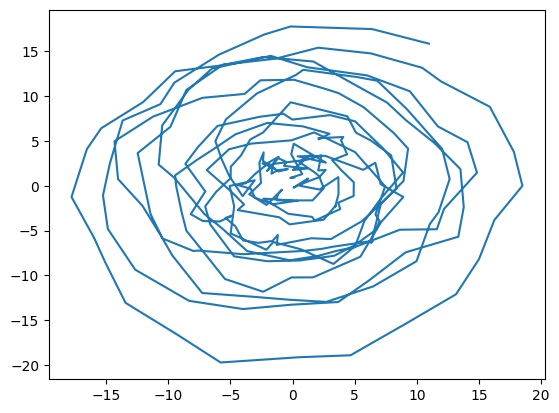

In [ ]:
plt.plot(X[:, 0], X[:, 1])